In [4]:
import pickle
import pandas as pd

In [40]:
model_path_prefix  = '../2_model_development/'
data_prefix = '../0_data/processed_data/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_types = ['RF', 'XGB', 'LGB']

In [41]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams


def shap_analysis(model, data_ro5, data_bro5, n=10):
    """
    Tornado-style side-by-side horizontal bar chart.
      - Left panel  : Ro5=1,  bars extend LEFT,  feature names at the LEFT tip of each bar
      - Right panel : Ro5=0,  bars extend RIGHT, feature names at the RIGHT tip of each bar
      - Features ordered top → bottom by importance (independently per group)
      - Both panels share the same x-axis limit (max of the two groups)
      - Feature label colour:
          blue  – unique to Ro5=1
          red   – unique to Ro5=0
          grey  – shared by both groups

    Parameters
    ----------
    model     : trained RF / XGB / LGB model
    data_ro5  : DataFrame – Ro5 == 1 subset
    data_bro5 : DataFrame – Ro5 == 0 subset
    n         : int – number of top features per group (default 10)

    Returns
    -------
    result_ro5, result_bro5, explainer_ro5, explainer_bro5
    """
    NON_FEAT    = ['SMILES', 'MP', 'Type', 'Ro5']
    model_class = type(model).__name__

    if model_class not in ('RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor'):
        raise ValueError(f"Unsupported model type: {model_class!r}")

    def _compute(data):
        X        = data.drop(columns=NON_FEAT, errors='ignore')
        exp      = shap.TreeExplainer(model)
        sv       = exp.shap_values(X)
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:n]
        feats    = X.columns[top_idx].tolist()
        vals     = mean_abs[top_idx]
        return X, sv, feats, vals, exp

    X1, sv1, feats1, vals1, exp1 = _compute(data_ro5)
    X0, sv0, feats0, vals0, exp0 = _compute(data_bro5)

    set1, set0 = set(feats1), set(feats0)

    # ── Colours ──────────────────────────────────────────────────────
    C1, C0           = '#2166AC', '#D6604D'
    C1_edge, C0_edge = '#1A4A7A', '#A03020'
    C_BOTH           = '#555555'

    def _label_color(feat, own_color):
        if feat in set1 and feat in set0:
            return C_BOTH
        return own_color

    rcParams.update({
        'font.family'      : 'sans-serif',
        'font.sans-serif'  : ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size'        : 10,
        'axes.linewidth'   : 0.8,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
    })

    # Shared x limit
    xmax = max(vals1.max(), vals0.max()) * 1.12

    panel_h = max(4, n * 0.45)
    fig = plt.figure(figsize=(16, panel_h), facecolor='white', dpi=150)
    gs  = fig.add_gridspec(1, 2, wspace=0.08, top=0.88, bottom=0.12,
                           left=0.05, right=0.95)
    ax1 = fig.add_subplot(gs[0, 0])   # left  – Ro5 = 1
    ax0 = fig.add_subplot(gs[0, 1])   # right – Ro5 = 0

    bh = 0.62
    # y positions: most important (index 0) at the top → highest y value
    y1 = np.arange(len(feats1) - 1, -1, -1)
    y0 = np.arange(len(feats0) - 1, -1, -1)
    gap = xmax * 0.025   # small offset from the bar tip

    # ── Left panel – Ro5=1, bars LEFT, labels at LEFT tip ────────────
    ax1.barh(y1, vals1, height=bh, color=C1, edgecolor=C1_edge,
             linewidth=0.5, zorder=3)
    ax1.set_xlim(0, xmax)
    ax1.invert_xaxis()                 # bars extend leftward; x=0 is on the right
    ax1.set_ylim(-0.6, len(feats1) - 0.4)
    ax1.set_yticks([])                 # no y-tick labels; we annotate manually
    ax1.tick_params(axis='x', labelsize=9, length=3)
    ax1.set_xlabel('Mean |SHAP value|', fontsize=11, labelpad=5)
    ax1.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['right'].set_linewidth(0.7)
    ax1.spines['bottom'].set_linewidth(0.7)
    ax1.set_title('Ro5 = 1  (drug-like)', fontsize=12, fontweight='bold',
                  color=C1, pad=9)

    # Feature names at the left tip (tip is at val; invert_xaxis means larger val = further left)
    for yi, (feat, val) in zip(y1, zip(feats1, vals1)):
        ax1.text(val + gap, yi, feat,
                 ha='right', va='center', fontsize=9, fontweight='bold',
                 color=_label_color(feat, C1), zorder=6)

    # ── Right panel – bRo5, bars RIGHT, labels at RIGHT tip ──────────
    ax0.barh(y0, vals0, height=bh, color=C0, edgecolor=C0_edge,
             linewidth=0.5, zorder=3)
    ax0.set_xlim(0, xmax)
    ax0.set_ylim(-0.6, len(feats0) - 0.4)
    ax0.set_yticks([])
    ax0.tick_params(axis='x', labelsize=9, length=3)
    ax0.set_xlabel('Mean |SHAP value|', fontsize=11, labelpad=5)
    ax0.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_linewidth(0.7)
    ax0.spines['bottom'].set_linewidth(0.7)
    ax0.set_title('Ro5 = 0  (beyond drug-like)', fontsize=12, fontweight='bold',
                  color=C0, pad=9)

    # Feature names at the right tip
    for yi, (feat, val) in zip(y0, zip(feats0, vals0)):
        ax0.text(val + gap, yi, feat,
                 ha='left', va='center', fontsize=9, fontweight='bold',
                 color=_label_color(feat, C0), zorder=6)

    # ── Title ────────────────────────────────────────────────────────
    fig.suptitle(
        f'Top-{n} SHAP Feature Importances  ·  {model_class}',
        fontsize=14, fontweight='bold', color='#222222', y=0.975
    )

    plt.show()

    # ── Attach SHAP values back to original DataFrames ───────────────
    def _attach(data, X, sv):
        df_s = pd.DataFrame(sv, columns=[f'shap_{c}' for c in X.columns],
                            index=data.index)
        return pd.concat([data, df_s], axis=1)

    return _attach(data_ro5, X1, sv1), _attach(data_bro5, X0, sv0), exp1, exp0



=== SHAP Analysis for XGB: Ro5=1 vs Ro5=0 ===


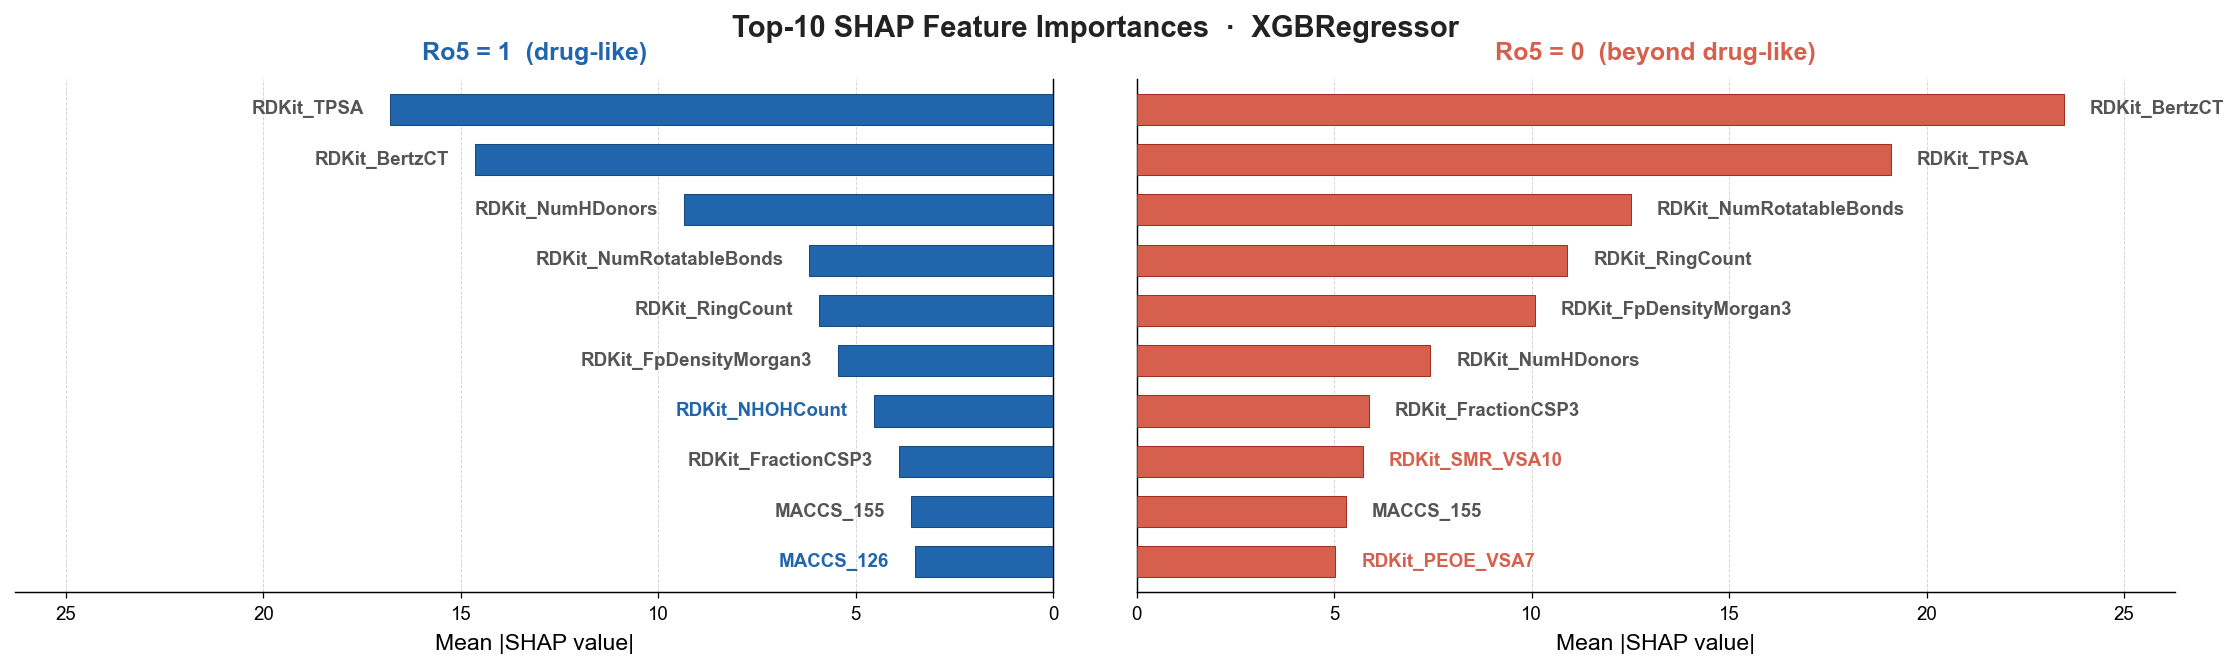


=== SHAP Analysis for LGB: Ro5=1 vs Ro5=0 ===


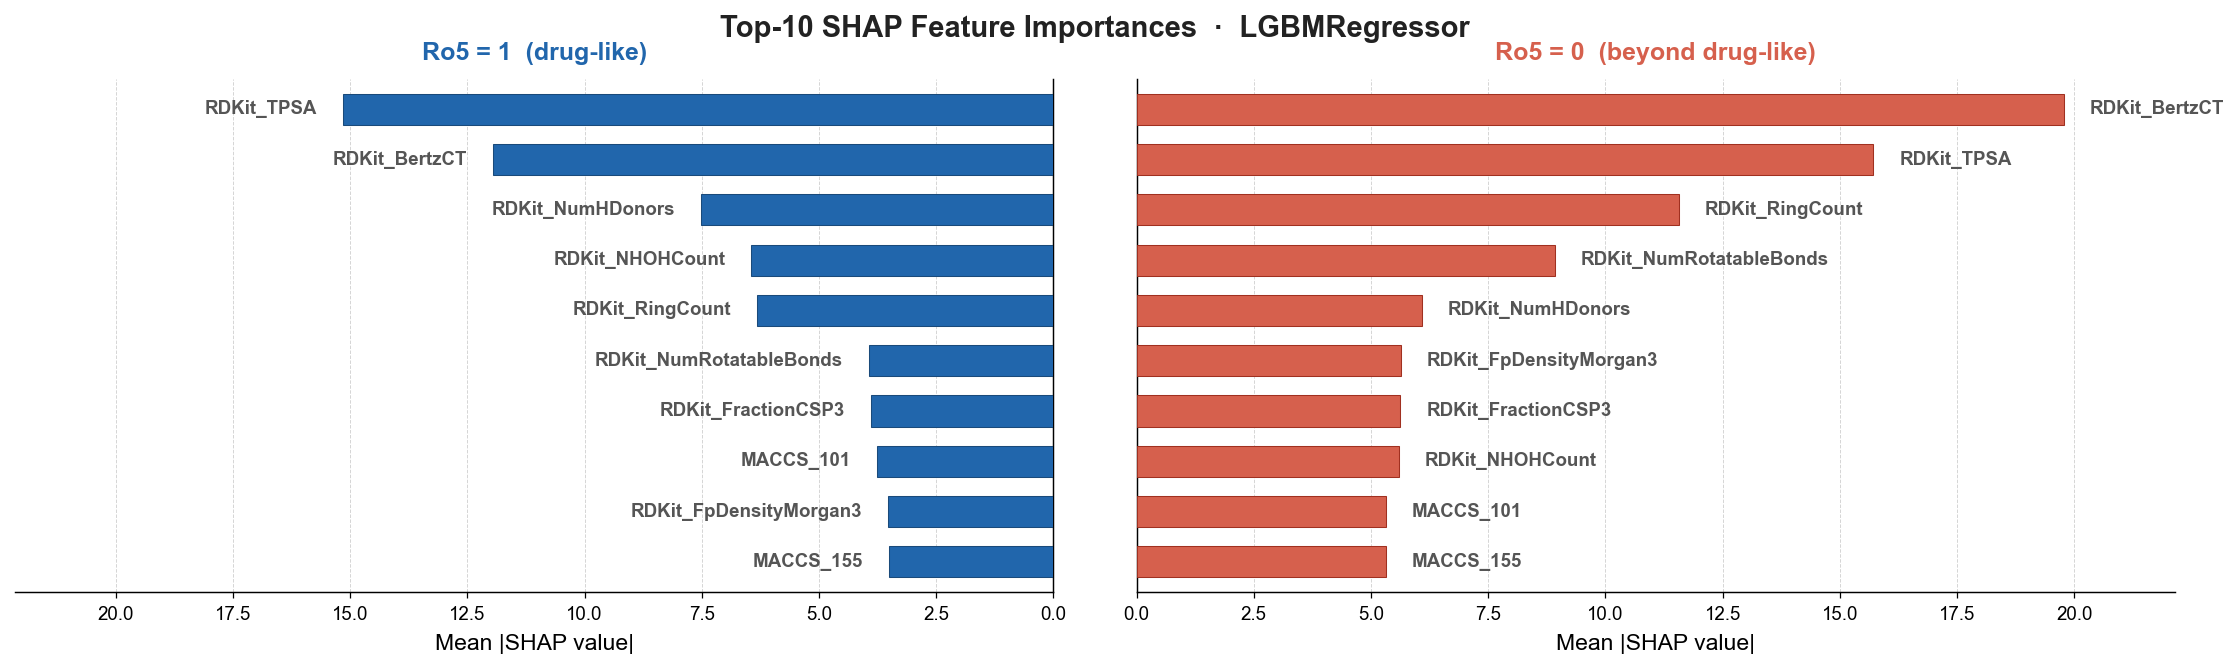

In [43]:
import joblib


for model_name in ['XGB', 'LGB']:
    print(f"\n=== SHAP Analysis for {model_name}: Ro5=1 vs Ro5=0 ===")

    model    = joblib.load(f"{model_path_prefix}best_model_{model_name}.joblib")
    all_data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model_name}_scaled.parquet")
    test     = all_data[all_data['Type'] == 'Test'].copy()

    data_ro5  = test[test['Ro5'] == 1].copy()
    data_bro5 = test[test['Ro5'] == 0].copy()

    result_ro5, result_bro5, exp_ro5, exp_bro5 = shap_analysis(
        model, data_ro5, data_bro5, n=10
    )
